# Renewable Asset Performance Monitor (RAPM)

## Engineering Asset Investigation using Python

**Author:** David Enwemuche

**Tools:** Python, Pandas, Numpy, Matplotlib

# Executive Summary
This project demostrates how python can be used to analyse renewable asset performance through time-series data processing,KPI reporting, anomaly detection and engineering decision-making.

The objective is to identify underperforming assets quickly and generate repeatable management-ready report that support operational decisions.

# Business Problem
Renewable operators manage large volumes of operational data.

Key challenges include:

    -Detecting underperforming assets.
    -Validating operational data.
    -Identifing equipment anomalies.
    -Producing consistent engineering reports.

Python automation reduces manual repoting effort while supporting faster technical decisions.


# Data Validation
Before analysing asset performance, the dataset is validated to ensure:

    -Missing values are identified.
    -Data formats are consistent.
    -Time-series records are correctly ordered.
    -Duplicate records are removed where necessary.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
BASE_DIR = Path().resolve()
DATA_FILE = BASE_DIR /"data"/"scada_data.csv"
REPORT_FOLDER = BASE_DIR/"reports"
CHART_FOLDER = BASE_DIR/"charts"

REPORT_FOLDER.mkdir(exist_ok = True)
CHART_FOLDER.mkdir(exist_ok = True)
print("ALL paths set up successfully!")
print(f"Working from:{BASE_DIR}")

ALL paths set up successfully!
Working from:C:\Users\enwem


In [4]:
print(f"Looking for file at:{DATA_FILE}")
print(f"Does the file exist? {DATA_FILE.exists()}")

Looking for file at:C:\Users\enwem\data\scada_data.csv
Does the file exist? True


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
BASE_DIR =Path()

DATA_FILE = BASE_DIR/"data"/"scada_data.csv"
REPORT_FOLDER = BASE_DIR/"reports"
CHART_FOLDER = BASE_DIR/"charts"

REPORT_FOLDER.mkdir(exist_ok= True)
CHART_FOLDER.mkdir(exist_ok= True)

print(f"Working from: {BASE_DIR.resolve()}")
print(f"csv exist? {DATA_FILE.exists()}")


Working from: C:\Users\enwem
csv exist? True


In [7]:
df = pd.read_csv(DATA_FILE)
print("Data File Loaded Successfully")
print(df.head())

Data File Loaded Successfully
    Time       Asset Technology  Power (MW)  Wind Speed Alarm
0  08:00  Wind Alpha       Wind         7.8         8.2   NaN
1  08:15  Wind Alpha       Wind         8.0         8.4   NaN
2  08:30  Wind Alpha       Wind         8.1         8.6   NaN
3  08:45  Wind Alpha       Wind         7.9         8.5   NaN
4  09:00  Solar Beta      Solar         4.8         0.0   NaN


In [8]:
DATA_FILE= BASE_DIR/"data"/"scada_data.csv"

In [9]:
print("\n DATA VALIDATION")
print(df.info())

print("\n Missing Values")
print(df.isnull().sum())

print("\n Duplicate Rows")
print(df.duplicated().sum())


 DATA VALIDATION
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time        12 non-null     str    
 1   Asset       12 non-null     str    
 2   Technology  12 non-null     str    
 3   Power (MW)  12 non-null     float64
 4   Wind Speed  12 non-null     float64
 5   Alarm       4 non-null      str    
dtypes: float64(2), str(4)
memory usage: 988.0 bytes
None

 Missing Values
Time          0
Asset         0
Technology    0
Power (MW)    0
Wind Speed    0
Alarm         8
dtype: int64

 Duplicate Rows
0


In [10]:
total_generation = df["Power (MW)"].sum()

average_generation = df["Power (MW)"].mean()

asset_summary = df.groupby("Asset").agg(
    Average_Output=("Power (MW)","mean"),
    Maximum_Output=("Power (MW)", "max"),
    Minimum_Output=("Power (MW)", "min"),
    Readings=("Power (MW)", "count"))
asset_summary = asset_summary.sort_values(by="Average_Output",ascending=False)
print(asset_summary)
print(f"total_generation):{total_generation:.2f} MW")
print(f"average_generation):{average_generation:.2f} MW")

#second methodtotal_generation = round(df["Power (MW)"].sum(),2)

#second methodaverage_generation = round(df["Power (MW)"].mean(),2)

    

             Average_Output  Maximum_Output  Minimum_Output  Readings
Asset                                                                
Wind Alpha            7.950             8.1             7.8         4
Solar Beta            4.175             4.9             3.4         4
Hydro Gamma           3.050             3.1             3.0         2
Wind Delta            2.150             2.2             2.1         2
total_generation):58.90 MW
average_generation):4.91 MW


In [11]:
asset_summary["Status"] = asset_summary["Average_Output"].apply(
    lambda x: "Investigate" if x <3 else "Close to Threshold" if x <=4 else "Normal")
print(asset_summary)

             Average_Output  Maximum_Output  Minimum_Output  Readings  \
Asset                                                                   
Wind Alpha            7.950             8.1             7.8         4   
Solar Beta            4.175             4.9             3.4         4   
Hydro Gamma           3.050             3.1             3.0         2   
Wind Delta            2.150             2.2             2.1         2   

                         Status  
Asset                            
Wind Alpha               Normal  
Solar Beta               Normal  
Hydro Gamma  Close to Threshold  
Wind Delta          Investigate  


In [12]:
alarm_summary = df[df["Alarm"].notna()&(df["Alarm"] != "None")]
print(alarm_summary)

     Time       Asset Technology  Power (MW)  Wind Speed          Alarm
6   09:30  Solar Beta      Solar         3.6         0.0       Inverter
7   09:45  Solar Beta      Solar         3.4         0.0       Inverter
10  10:30  Wind Delta       Wind         2.2         8.3  Pitch Warning
11  10:45  Wind Delta       Wind         2.1         8.4  Pitch Warning


In [13]:
#making it smarter
alarm_count = (
    alarm_summary.groupby(["Asset","Alarm"])
    .size()
    .reset_index(name="Occurrences")
)
print(alarm_count)

        Asset          Alarm  Occurrences
0  Solar Beta       Inverter            2
1  Wind Delta  Pitch Warning            2


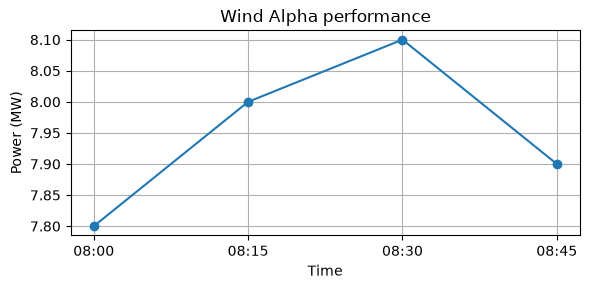

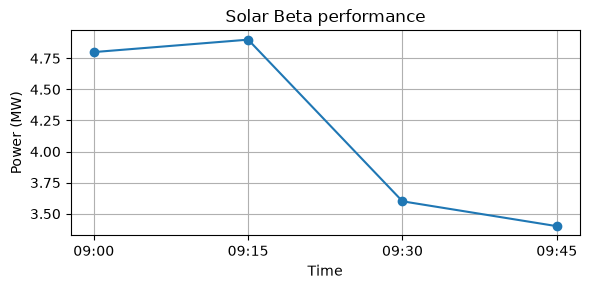

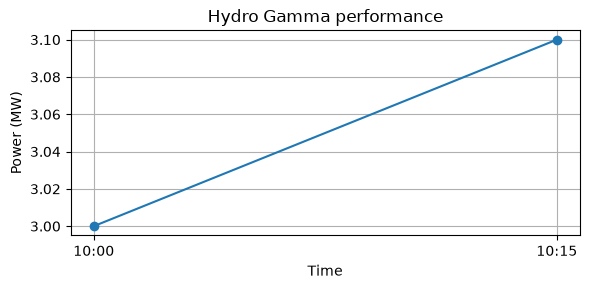

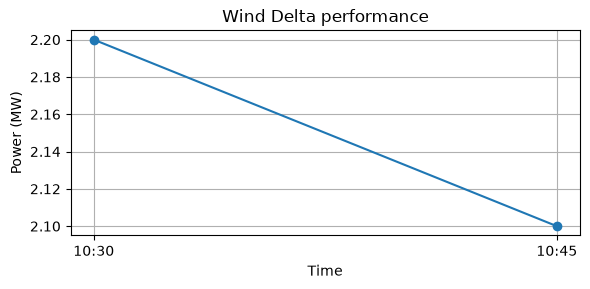

In [14]:
#Automatical chart
for asset in df["Asset"].unique():
    asset_data = df[df["Asset"] == asset]
    
    plt.figure(figsize=(6,3))

    plt.plot(asset_data["Time"],
                asset_data["Power (MW)"],
                marker = "o")
    plt.title(f"{asset} performance")
    plt.xlabel("Time")
    plt.ylabel("Power (MW)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(CHART_FOLDER / f"{asset}.png")
    plt.show()
    plt.close()

In [39]:
#Report data in excel
report_file = REPORT_FOLDER / "Daily_Asset_Report.xlsx"
with pd.ExcelWriter(report_file) as writer:
    asset_summary.to_excel(
        writer,
        sheet_name = "Alarm Summary"
    )

    alarm_count.to_excel(
        writer,
        sheet_name = "Alarm Summary",
        index = False
    )
    
    df.to_excel(
        writer,
        sheet_name = "Raw_Data",
        index = False
    )

In [44]:
priority_asset = asset_summary["Average_Output"].idxmin()

summary = f"""
GREENPOWER DAILY PERFOMANCE SUMMARY

Total Generation: {total_generation:.2f} MW
Average Generation: {average_generation: .2f} MW

Priority_ Asset: {priority_asset}

Active Alarm Events: {len(alarm_summary)}

Recommendation:
Investigate {priority_asset} immediately and continue monitoring all active alarms.
"""
print(summary)



GREENPOWER DAILY PERFOMANCE SUMMARY

Total Generation: 58.90 MW
Average Generation:  4.91 MW

Priority_ Asset: Wind Delta

Active Alarm Events: 4

Recommendation:
Investigate Wind Delta immediately and continue monitoring all active alarms.



# KPI Analysis
The project calculates key operational indicators including:

    -Generation
    -Availability
    -Capacity utilisation
    -Downtime
    -Performance trends

# Engineering Investigation
### Example Scenario
Solar Beta is producing 3.6 MW instead of the expected 5.0 MW.

Engineering approach:
1. Validate operational data
2. Review inverter alarms
3. Compare historical performance
4. Assess production impact
5. Recommend corrective action
6. Continue monitoring after investigation


# Engineering Recommendation
Python provides a repeatable workflow for monitoring renewable assets, validating operational data and generating engineering reports.

Future improvements include API investigation, live SCADA connectivity and automated email reporting